In [1]:
import pandas as pd
from src import *
allimages = pd.read_csv("Tables/All_Subjects_All_Images_20Feb2026.csv")
diagnosis = pd.read_csv("Tables/All_Subjects_DXSUM_20Feb2026.csv")

In [2]:
# Load table of all images
allimages = pd.read_csv("Tables/All_Subjects_All_Images_20Feb2026.csv")

In [3]:
# Print total number of images
len(allimages[allimages.modality=="MRI"])

230002

In [4]:
# Info of all MRI images
mris = allimages[
    (allimages.modality=="MRI")&
    (allimages.image_type=="Original")
    ]

In [5]:
# Print top 50 frequent MRI image descriptions
mris.image_description.value_counts()[:50]

image_description
3 Plane Localizer                      12014
localizer                               7604
Axial 3D ME T2 GRE (MSV21)              7183
3-plane localizer                       5823
MPRAGE                                  5558
Field Mapping                           5522
Axial PD-T2 TSE                         3942
Axial PD/T2 FSE                         3822
Localizer                               3288
Axial T2-FLAIR                          3041
Axial T2 Star                           2370
Sagittal 3D FLAIR                       2324
Axial 3TE T2 STAR                       2256
AXIAL_T2_STAR                           2075
MPRAGE GRAPPA2                          2061
MP-RAGE                                 2037
MPRAGE Repeat                           1961
B1-calibration Body                     1897
B1-calibration Head                     1866
MP-RAGE REPEAT                          1669
HighResHippo                            1487
B1-Calibration Body                  

In [6]:
# MRIs from ADNI 3 and 4
mris_adni34 = mris[(mris.phase=="ADNI 3")|(mris.phase=="ADNI 4")]
len(mris_adni34)

37622

In [7]:
# Load table of diagnosis
diagnosis = pd.read_csv("Tables/All_Subjects_DXSUM_20Feb2026.csv")
diagnosis.USERDATE = diagnosis.USERDATE.apply(pd.to_datetime)

In [8]:
# Per phase diagnosis
diagnosis_phase = {}
for i in [1,"GO",2,3,4]:
    diagnosis_phase[i] = diagnosis[diagnosis.PHASE==f"ADNI{i}"]

In [9]:
# Print counts of patients in each phase
for i in [1,"GO",2,3,4]:
    print(f"Count of patients in phase {i}: {diagnosis_phase[i].PTID.nunique()}")

p = [1,"GO",2,3,4]
for i in range(4):
    print(f"Count of patients in phase {p[i]} that didn't continue in phase {p[i+1]}: {diagnosis_phase[p[i]][~diagnosis_phase[p[i]].PTID.isin(diagnosis_phase[p[i+1]].PTID)].PTID.nunique()}")

Count of patients in phase 1: 819
Count of patients in phase GO: 338
Count of patients in phase 2: 1438
Count of patients in phase 3: 1376
Count of patients in phase 4: 1339
Count of patients in phase 1 that didn't continue in phase GO: 610
Count of patients in phase GO that didn't continue in phase 2: 41
Count of patients in phase 2 that didn't continue in phase 3: 1028
Count of patients in phase 3 that didn't continue in phase 4: 860


In [10]:
# Total number of unique patients
diagnosis.PTID.nunique()

3789

In [11]:
allimages3 = allimages[(allimages.phase=="ADNI 3")&(allimages.modality=="MRI")]

In [12]:
cn = diagnosis[diagnosis.DIAGNOSIS==1.0][["PTID","USERDATE","DIAGNOSIS"]]
mci = diagnosis[diagnosis.DIAGNOSIS==2.0][["PTID","USERDATE","DIAGNOSIS"]]
ad = diagnosis[diagnosis.DIAGNOSIS==3.0][["PTID","USERDATE","DIAGNOSIS"]]

In [13]:
#### Transition patients
patients = pd.merge(cn,ad,on="PTID")
times = patients.groupby("PTID")["USERDATE_y"].max()-patients.groupby("PTID")["USERDATE_x"].min()
cleaned_times = times[times>pd.Timedelta(0)]
len(cleaned_times)

### No transition patients:
# patients = mci[(~mci.PTID.isin(cn.PTID))&(~mci.PTID.isin(ad.PTID))]
# times = patients.groupby("PTID")["USERDATE"].max()-patients.groupby("PTID")["USERDATE"].min()
# cleaned_times = times
# times

52

In [14]:
visits = allimages3[allimages3.subject_id.isin(cleaned_times.index)]

In [15]:
# Average number of visits
visits.groupby("subject_id")["image_date"].unique().apply(len).mean()

np.float64(2.5)

In [16]:
# Average duration
times.mean()

Timedelta('3328 days 08:26:40')

In [17]:
# All t1w images
mris_t1w = mris[
    mris.image_description.str.contains("RAGE")|
    mris.image_description.str.contains("SPGR")
    ]
len(mris_t1w)

23875

In [18]:
mris_t1w.image_description.value_counts()[:20]

image_description
MPRAGE                                 5558
MPRAGE GRAPPA2                         2061
MP-RAGE                                2037
MPRAGE Repeat                          1961
MP-RAGE REPEAT                         1669
Accelerated Sagittal MPRAGE            1445
Accelerated Sagittal MPRAGE (MSV21)     948
MPRAGE SENSE2                           856
Sag IR-SPGR                             689
Accelerated Sag IR-FSPGR                683
Sag IR-FSPGR                            430
Accelerated SAG IR-SPGR                 414
Sagittal 3D Accelerated MPRAGE          355
MPRAGE_GRAPPA2                          334
Accelerated Sag IR-SPGR                 280
MP-RAGE-Repeat                          268
Accelerated Sagittal MPRAGE_ND          258
Accelerated Sagittal IR-FSPGR           258
IR-FSPGR-Repeat                         164
IR-FSPGR                                154
Name: count, dtype: int64

In [19]:
# All T1w images in ADNI 3&4

mris_34_t1w = mris_adni34[
    mris_adni34.image_description.str.contains("RAGE")|
    mris_adni34.image_description.str.contains("SPGR")
    ]
len(mris_34_t1w)

4199

In [20]:
# Number of unique patients with T1w in ADNI 3&4

mris_34_t1w.subject_id.nunique()

1796

In [21]:
mris_34_t1w.image_date = mris_34_t1w.image_date.apply(pd.to_datetime)
span_counts34 = mris_34_t1w.groupby("subject_id")["image_date"].agg(lambda x:x.max()-x.min())

C:\Users\Shichen\AppData\Local\Temp\ipykernel_39004\1396892696.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mris_34_t1w.image_date = mris_34_t1w.image_date.apply(pd.to_datetime)


In [22]:
# Number of patients in ADNI 3&4 with duration > 3 years
len(span_counts34[span_counts34>pd.Timedelta("1056 days")])

504

In [23]:
mris_t1w.image_date = mris_t1w.image_date.apply(pd.to_datetime)
span_counts = mris_t1w.groupby("subject_id")["image_date"].agg(lambda x:x.max()-x.min())

C:\Users\Shichen\AppData\Local\Temp\ipykernel_39004\748577548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mris_t1w.image_date = mris_t1w.image_date.apply(pd.to_datetime)


In [24]:
# Number of patients with duration > 1 years
len(span_counts[span_counts>pd.Timedelta("365 days")])

2056

In [25]:
biomark = pd.read_csv("Tables/All_Subjects_BIOMARK_20Feb2026.csv",low_memory=False)

In [26]:
biomark.update_stamp = biomark.update_stamp.apply(pd.to_datetime)
biomark_span = biomark.groupby("PTID")["update_stamp"].agg(lambda x:x.max()-x.min())

In [27]:
len(biomark_span[biomark_span>pd.Timedelta("360 days")])

1929

In [28]:
biomark_adni34 = biomark[
    (biomark.PHASE=="ADNI3")|
    (biomark.PHASE=="ADNI4")
    ]

In [29]:
biomark_adni34.update_stamp = biomark_adni34.update_stamp.apply(pd.to_datetime)
biomark_adni34_span = biomark_adni34.groupby("PTID")["update_stamp"].agg(lambda x:x.max()-x.min())

C:\Users\Shichen\AppData\Local\Temp\ipykernel_39004\1284263072.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biomark_adni34.update_stamp = biomark_adni34.update_stamp.apply(pd.to_datetime)


In [30]:
len(biomark_adni34_span[biomark_adni34_span>pd.Timedelta("365 days")])

803

In [31]:
merged = pd.merge(biomark_adni34_span,span_counts34,left_on="PTID",right_on="subject_id")

In [32]:
len(merged)

1581

In [33]:
t = pd.Timedelta("1095 days")
len(merged[(merged.update_stamp>t)&(merged.image_date>t)])

443

In [34]:
# Study the following tables
dti = pd.read_csv("Tables/All_Subjects_DTIROI_MEAN_20Feb2026.csv")
robust = pd.read_csv("Tables/All_Subjects_DTIROI_ROBUSTMEAN_20Feb2026.csv")
bsi = pd.read_csv("Tables/All_Subjects_FOXLABBSI_20Feb2026.csv")
bsi = bsi[bsi.PHASE.isin(["ADNI3","ADNI4"])]
fs = pd.read_csv("Tables/All_Subjects_UCSFFSX7_20Feb2026.csv",low_memory=False)
fs = fs[fs.PHASE.isin(["ADNI3","ADNI4"])]
table_to_study = fs

In [35]:
fs

,PHASE,PTID,RID,VISCODE,VISCODE2,IMAGEUID,FIELD_STRENGTH,EXAMDATE,RUNDATE,STATUS,...,ST147SV,ST148SV,ST149SV,ST150SV,ST151SV,ST152SV,ST153SV,ST154SV,ST155SV,update_stamp
0,ADNI3,002_S_4213,4213,init,m72,888008,3T,2017-08-14,2022-07-23,partial,...,217434.885092,217173.802571,434608.687663,175240.0,171111.0,346351.0,47936.0,576920.687663,874725.0,2024-12-02 08:27:54
6,ADNI3,041_S_5253,5253,y4,m102,1576293,3T,2022-04-05,2022-09-30,partial,...,224326.718919,227507.621279,451834.340198,277026.0,265788.0,542814.0,56219.0,627853.340198,1088080.0,2024-12-02 08:27:54
8,ADNI3,035_S_6480,6480,y1,m12,1194953,3T,2019-07-31,2024-11-19,partial,...,243787.275324,250039.192742,493826.468066,218554.5,216599.5,435154.0,56660.0,669236.468066,1040202.0,2024-12-02 08:27:54
12,ADNI4,941_S_6471,6471,4_m12,m72,10932490,3T,2024-08-27,2024-10-16,complete,...,246390.072695,246485.281979,492875.354675,239296.5,239755.5,479052.0,61836.0,671169.354675,1052429.0,2024-12-02 08:27:54
13,ADNI3,168_S_6086,6086,sc,sc,917090,3T,2017-10-13,2022-07-26,partial,...,221605.243687,223505.738449,445110.982136,211261.5,207829.5,419091.0,55916.0,602435.982136,969703.0,2024-12-02 08:27:54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12224,ADNI4,941_S_7074,7074,4_m24,m42,11455284,3T,2025-10-01,2025-10-31,complete,...,219905.755164,219104.695787,439010.450951,192598.0,191468.0,384066.0,50991.0,582962.450951,910066.0,2026-01-16 12:03:30
12225,ADNI4,006_S_6243,6243,4_m24,m90,11494945,3T,2025-11-19,2026-01-06,complete,...,235507.672331,234696.915662,470204.587993,241856.5,240102.5,481959.0,57991.0,650340.587993,1050096.0,2026-01-16 12:03:30
12226,ADNI4,389_S_10070,10070,4_m12,m18,11488775,3T,2025-11-14,2026-01-06,complete,...,265529.067888,260959.211646,526488.279535,246891.0,239864.0,486755.0,63323.0,709839.279535,1117553.0,2026-01-16 12:03:30
12227,ADNI4,073_S_10006,10006,4_m24,m24,11468696,3T,2025-10-13,2026-01-05,complete,...,250778.033848,265470.115442,516248.149290,236375.0,243449.0,479824.0,52932.0,675785.149290,1068338.0,2026-01-16 12:03:30


In [36]:
from src import getyear
table_to_study = table_to_study.copy()
table_to_study["year"] = table_to_study.VISCODE.map(getyear)

In [37]:
merged = table_to_study.merge(diagnosis.drop("EXAMDATE",axis=1),on=["PTID","VISCODE"])
merged = merged[~merged.DIAGNOSIS.isna()]
merged.DIAGNOSIS = merged.DIAGNOSIS.apply(int)

In [38]:
merged.isna().sum().sort_values()[-50:]
# drop those columns with too many null values. Those columns most likely do not contain valuable information.

ST35CV                   361
ST48TS                   361
ST48TA                   361
ST48SA                   361
ST48CV                   361
ST38TS                   361
ST38TA                   361
ST38SA                   361
ST38CV                   361
ST107SA                  361
ST107CV                  361
DXMDUE                  2158
DXMDES                  2162
DXMPTR1                 2164
DXMPTR6                 2164
DXMPTR4                 2164
DXMPTR3                 2167
DXMPTR5                 2168
DXMPTR2                 2169
DD_CRF_VERSION_LABEL    2256
HAS_QC_ERROR            2256
LANGUAGE_CODE           2256
BGQC                    2258
TEMPQC                  2258
INSULAQC                2258
OVERALLQC               2258
FRONTQC                 2258
OCCQC                   2258
PARQC                   2258
VENTQC                  2258
HIPPOQC                 2258
CWMQC                   2258
DXDSEV                  3012
DXDDUE                  3012
DXAPP         

In [39]:
merged = merged.dropna(axis=1,thresh=len(merged)-1000)
# merged = merged.drop(["RID_x","RID_y","IMAGEUID"],axis=1)
merged

,PHASE_x,PTID,RID_x,VISCODE,VISCODE2_x,IMAGEUID,FIELD_STRENGTH,EXAMDATE,RUNDATE,STATUS,...,RID_y,VISCODE2_y,DIAGNOSIS,DXPARK,DXDEP,ID,SITEID,USERDATE,USERDATE2,update_stamp_y
0,ADNI3,002_S_4213,4213,init,m72,888008,3T,2017-08-14,2022-07-23,partial,...,4213,m72,1,0.0,0.0,10647,1,2017-08-18,2017-08-18,2017-08-17 22:44:55
1,ADNI3,041_S_5253,5253,y4,m102,1576293,3T,2022-04-05,2022-09-30,partial,...,5253,m102,2,0.0,0.0,156076,28,2022-05-05,2022-05-05,2022-05-06 04:18:11
2,ADNI3,035_S_6480,6480,y1,m12,1194953,3T,2019-07-31,2024-11-19,partial,...,6480,m12,2,0.0,0.0,92304,25,2019-08-07,2019-08-07,2019-08-08 04:15:41
3,ADNI4,941_S_6471,6471,4_m12,m72,10932490,3T,2024-08-27,2024-10-16,complete,...,6471,m72,1,0.0,0.0,31696,941,2024-09-03,2024-09-03,2024-09-04 01:49:51
4,ADNI3,168_S_6086,6086,sc,sc,917090,3T,2017-10-13,2022-07-26,partial,...,6086,sc,1,0.0,0.0,17412,58,2017-10-20,2017-10-20,2017-10-20 22:28:07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3397,ADNI4,941_S_7074,7074,4_m24,m42,11455284,3T,2025-10-01,2025-10-31,complete,...,7074,m42,1,0.0,0.0,120009,941,2025-09-11,2025-09-11,2025-09-12 01:53:05
3398,ADNI4,006_S_6243,6243,4_m24,m90,11494945,3T,2025-11-19,2026-01-06,complete,...,6243,m90,1,0.0,0.0,133591,6,2026-01-13,2026-01-13,2026-01-14 00:56:57
3399,ADNI4,389_S_10070,10070,4_m12,m18,11488775,3T,2025-11-14,2026-01-06,complete,...,10070,m18,2,0.0,0.0,132693,389,2025-12-23,2025-12-23,2025-12-24 00:58:05
3400,ADNI4,073_S_10006,10006,4_m24,m24,11468696,3T,2025-10-13,2026-01-05,complete,...,10006,m24,1,0.0,0.0,124255,73,2025-10-09,2025-10-09,2025-10-10 01:51:58


In [40]:
merged_num = merged.select_dtypes(include=['number'])
merged_num.year

0       0
1       4
2       1
3       1
4      -1
       ..
3397    2
3398    2
3399    1
3400    2
3401    1
Name: year, Length: 3399, dtype: int64

In [41]:
merged_num.corrwith(merged_num.year).sort_values()[:20]

RID_x      -0.436507
RID_y      -0.436507
IMAGEUID   -0.298971
ST51TA     -0.134058
SITEID     -0.128224
ST58TA     -0.126469
ST110TA    -0.114275
ST117TA    -0.110408
ST15TA     -0.102121
ST59TA     -0.101506
ST18SV     -0.101132
ST118TA    -0.099566
ST61SV     -0.098212
ST74TA     -0.097631
ST31TA     -0.096205
ST120SV    -0.094606
ST12SV     -0.094585
ST104TA    -0.094181
ST90TA     -0.091932
ST56TA     -0.091374
dtype: float64

In [42]:
merged_num.corrwith(merged_num.DIAGNOSIS).sort_values()[-20:]

ST46TS       0.167563
ST115TS      0.167883
ST74TS       0.170246
ST13TS       0.171485
ST47TS       0.176170
ST128SV      0.179870
ST15TS       0.180472
ST26TS       0.185527
ST55TS       0.192400
ST56TS       0.193962
ST80SV       0.208186
ST54TS       0.218356
ST21SV       0.237157
ST7SV        0.244265
ST96SV       0.273717
ST127SV      0.276297
ST37SV       0.291046
ST30SV       0.397657
ST89SV       0.408526
DIAGNOSIS    1.000000
dtype: float64

In [43]:
import pandas as pd


# Run the function
anova_summary_diagnosis = run_batch_anova(merged_num, 'DIAGNOSIS')

# View the top 10 most significant features
print(anova_summary_diagnosis.head(50))

    Feature  F-Statistic        P-Value
0    ST29SV   390.793714  8.616958e-153
1    ST89SV   371.621136  1.499957e-146
2    ST24TA   364.975567  1.214998e-143
3    ST30SV   353.825031  3.421093e-140
4    ST83TA   333.706507  1.752859e-132
5    ST88SV   322.788393  1.406539e-128
6    ST12SV   292.366974  1.931667e-117
7    ST58TA   272.146773  8.934420e-110
8    ST40TA   264.700604  5.191482e-107
9    ST90TA   220.376535   2.183778e-90
10   ST31TA   219.694008   3.978881e-90
11  ST117TA   210.940415   1.023295e-86
12   ST71SV   210.072833   1.678326e-86
13   ST26TA   201.896640   4.373985e-83
14   ST59TA   196.425589   3.478623e-81
15   ST99TA   196.474264   3.759269e-81
16   ST70SV   194.088377   1.616673e-80
17   ST52TA   190.364663   4.577289e-79
18   ST85TA   181.185464   4.311855e-75
19   ST11SV   179.246785   1.030321e-74
20  ST111TA   177.555406   4.757434e-74
21  ST118TA   170.291934   5.288985e-71
22  ST130TA   167.967189   2.915190e-70
23   ST40CV   162.965179   4.385651e-68


In [44]:
anova_summary_year = run_batch_anova(merged_num, 'year')
print(anova_summary_year.head(50))

      Feature  F-Statistic       P-Value
0       RID_x   368.728469  0.000000e+00
1          ID   543.153213  0.000000e+00
2       RID_y   368.728469  0.000000e+00
3    IMAGEUID    76.131866  1.795518e-89
4   DIAGNOSIS    39.926200  3.467690e-47
5      ST98TS    31.733592  2.720792e-37
6     ST113TS    29.869605  4.473623e-35
7     ST127SV    28.362713  3.010015e-33
8      ST54TS    27.407963  4.288426e-32
9     ST129TS    25.970314  2.390665e-30
10     ST96SV    25.917628  2.775196e-30
11     ST39TS    25.653532  6.101549e-30
12    ST115TS    25.355824  1.400768e-29
13    ST114TS    25.106783  2.807704e-29
14     ST89SV    24.642590  9.804795e-29
15     ST91TS    24.598128  1.219566e-28
16     ST37SV    24.400808  1.928198e-28
17     ST32TS    24.340836  2.499896e-28
18     ST36TS    23.678164  1.448230e-27
19     ST56TS    23.117154  7.289850e-27
20     ST30SV    22.375111  5.590294e-26
21     ST95TS    21.823050  2.611000e-25
22     ST55TS    21.770394  3.151013e-25
23    ST130TS   

In [45]:
anova_summary_cross = run_batch_anova(merged_num[["year","DIAGNOSIS"]], 'DIAGNOSIS')
anova_summary_cross

,Feature,F-Statistic,P-Value
0,year,0.400264,0.670175


In [46]:
import seaborn as sns

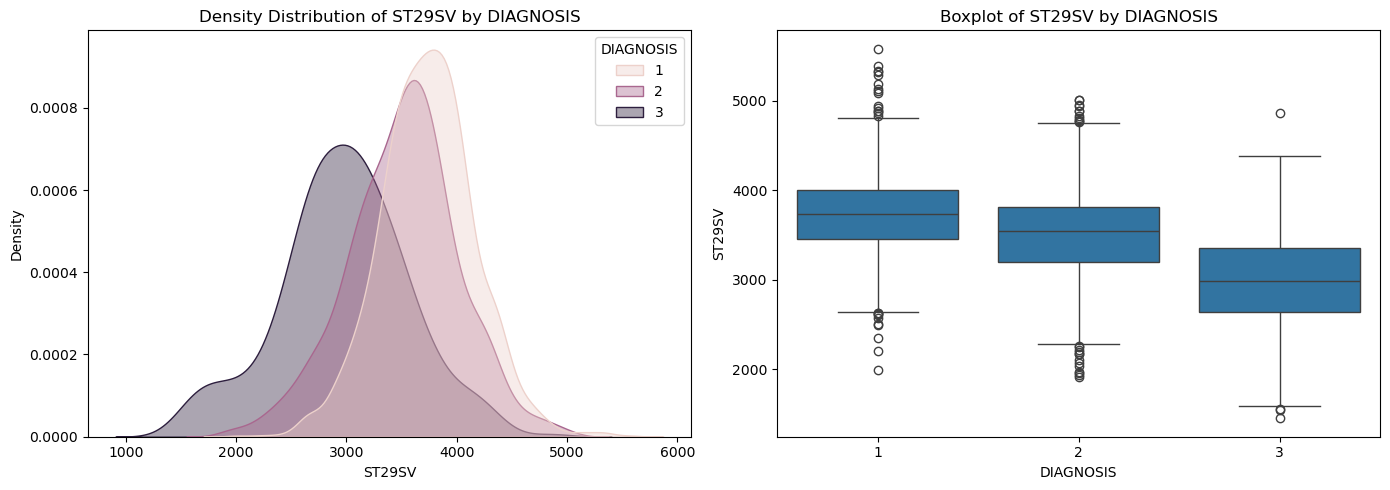

In [47]:
plot_diagnosis_distribution(merged_num, 'ST29SV')

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



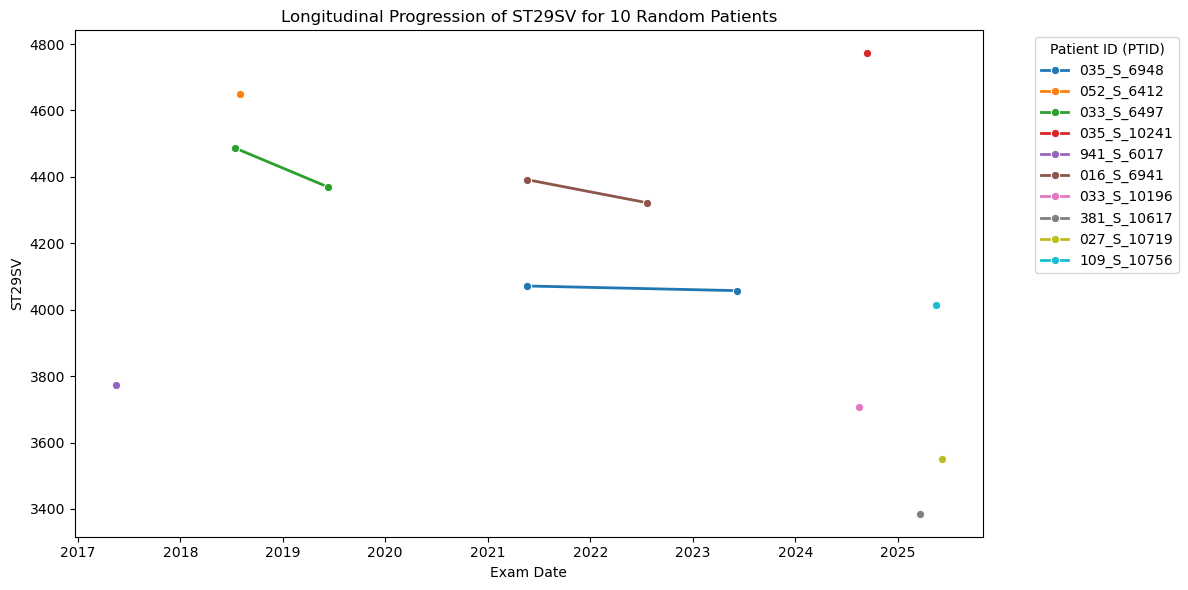

In [49]:
plot_patient_progression(table_to_study, 'ST29SV')

In [50]:
my_patients = list(patients.PTID.unique())

In [51]:
import random
cn_patients = random.choices(list(cn.PTID.unique()),k=50)
mci_patients = random.choices(list(mci.PTID.unique()),k=50)
ad_patients = random.choices(list(ad.PTID.unique()),k=50)
all_patients = cn_patients+mci_patients+ad_patients

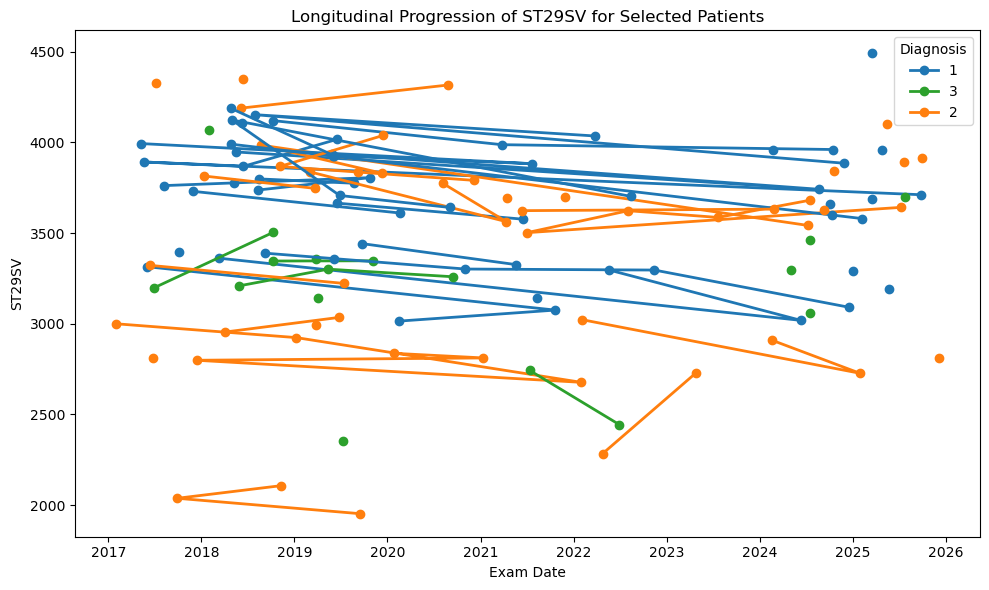

In [52]:
plot_specific_patients(merged, 'ST29SV', all_patients)

In [53]:
merged[merged.PTID.isin(mci_patients)]

,PHASE_x,PTID,RID_x,VISCODE,VISCODE2_x,IMAGEUID,FIELD_STRENGTH,EXAMDATE,RUNDATE,STATUS,...,RID_y,VISCODE2_y,DIAGNOSIS,DXPARK,DXDEP,ID,SITEID,USERDATE,USERDATE2,update_stamp_y
51,ADNI3,168_S_6619,6619,y2,m24,1382659,3T,2020-12-07,2022-07-26,partial,...,6619,m24,2,0.0,0.0,124935,58,2020-12-11,2020-12-11,2020-12-12 04:15:17
70,ADNI4,033_S_6976,6976,4_init,m36,10883387,3T,2024-07-15,2024-11-13,complete,...,6976,m36,2,0.0,0.0,25346,33,2024-07-30,2024-07-30,2024-07-31 01:47:15
171,ADNI3,135_S_6411,6411,y2,m24,1331222,3T,2020-08-26,2022-07-26,partial,...,6411,m24,2,0.0,0.0,119879,52,2020-09-24,2020-09-24,2020-09-25 04:16:18
206,ADNI3,301_S_6698,6698,sc,sc,1149157,3T,2019-03-29,2022-08-01,partial,...,6698,sc,2,0.0,1.0,77692,61,2019-03-11,2019-03-11,2019-03-11 22:33:03
218,ADNI3,123_S_1300,1300,init,m120,863941,3T,2017-06-26,2022-09-13,partial,...,1300,m120,2,0.0,0.0,45826,45,2018-06-05,2018-06-05,2018-06-05 22:37:42
339,ADNI3,067_S_6912,6912,sc,sc,1433667,3T,2021-04-15,2022-08-13,partial,...,6912,sc,2,0.0,0.0,130069,33,2021-03-30,2021-03-30,2021-03-31 04:16:31
379,ADNI3,301_S_6326,6326,sc,sc,989757,3T,2018-04-26,2022-08-01,partial,...,6326,sc,1,NaN,NaN,40445,61,2018-04-30,2018-04-30,2018-04-30 22:36:16
380,ADNI3,032_S_6279,6279,y1,m12,1181388,3T,2019-06-27,2022-09-13,partial,...,6279,m12,2,0.0,0.0,101678,23,2019-11-04,2019-11-04,2019-11-05 04:18:52
481,ADNI3,135_S_6411,6411,sc,sc,1005341,3T,2018-06-04,2022-07-26,partial,...,6411,sc,1,0.0,0.0,46530,52,2018-06-08,2018-06-08,2018-06-08 22:37:32
595,ADNI3,037_S_6141,6141,y1,m12,1146201,3T,2019-03-22,2022-08-13,partial,...,6141,m12,2,0.0,1.0,82297,27,2019-05-08,2019-05-08,2019-05-09 04:33:05
